# Deep Learning Mini Project - Fashionable Neural Networks 👕👗🥾

Neural networks are at the heart of many of today’s artificial intelligence applications, powering technologies such as image recognition, computer vision, natural language processing, and large language models. Their ability to learn complex patterns from data makes them one of the fundamental building blocks of modern AI.  

For this mini project, I decided to put a neural network to the test on a dataset that is quite literally fashionable: the Fashion-MNIST dataset. Rather than recognizing handwritten digits like the original MNIST dataset, Fashion-MNIST challenges a neural network to identify different types of clothing and footwear from 28 × 28 pixel grayscale images.
The dataset contains 70,000 images across 10 different classes:

| Label | Class |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |  

The goal of this mini project is to build and train a neural network that can learn the visual patterns associated with these categories and accurately classify previously unseen images.
So, while the dataset is about fashion, the real focus of this project is on one of the models that has become truly fashionable in the AI world: neural networks.

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

## Check the GPU

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Load the dataset

In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)
y_train: (60000,)
y_test: (10000,)


In [5]:
# Each image consists of a single color channel, where pixels range from 0 (completely black) to 255 (completely white), with shades of gray in between
# Because they are grayscale, their dimensions are a flat 28×28 pixels
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
# There are 10 different classes; so we have to build a multi-class classification neural network
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Showing X_train[8776], Label: 9, Clothing Article: Boot


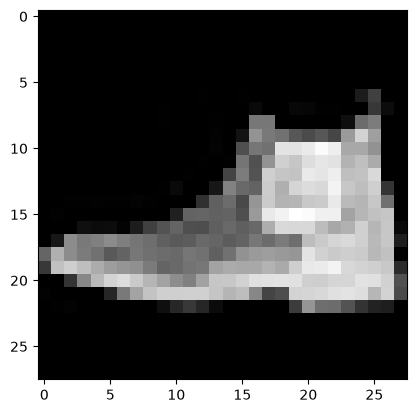

In [7]:
# Randomly select an image

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

# Select a random observation
img_idx = np.random.randint(0,len(X_train)-1)

print(f'Showing X_train[{img_idx}], Label: {y_train[img_idx]}, Clothing Article: {class_names[y_train[img_idx]]}')
plt.imshow(X_train[img_idx], cmap='gray');

## Scale the data

In [8]:
# Image pixels are stored as integers from 0 to 255. If raw 0-255 values are fed into a neural network as they are, the large numbers 
# will cause the gradients to explode, and the model will struggle to learn.

# To fix this, you simply divide by 255 to scale everything between 0 and 1
X_train, X_test = X_train/255, X_test/255

## Add a channel dimension

In [9]:
# Black and white images => 1 channel only; Colour images => 3 channels (RGB)

X_train = np.expand_dims(X_train, 3)
X_test = np.expand_dims(X_test, 3)
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


## Model Defintion

In [10]:
# Build the Network
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(28, 28, 1)),     
    tf.keras.layers.Flatten(),                # Flattens 2D images to 1D vectors

    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),     # Normalize activations to improve training stability
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),             # Randomly drop 20% of neurons to reduce overfitting

    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax') # 10 outputs for 10 clothing types
])

model.summary()

I0000 00:00:1789240813.380571 4379923 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789240813.380589 4379923 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

## Compile the Model

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # if we use categorical_crossentropy, we'll need to do one-hot encoding on labels
    metrics=['accuracy'],
)

## Train the model

In [12]:
# Enable Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Can also monitor val_loss
    patience=5,                  # Stop if val_accuracy doesn't improve for 5 epochs
    restore_best_weights=True    # Restores model weights from the peak epoch
)

# Define Model Checkpoint - automatically saves the absolute best version of the model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_fashion_mnist_model.keras',
    monitor='val_accuracy',      # Can also monitor val_loss
    save_best_only=True          # Only save to disk when val_loss improves
)

In [13]:
history = model.fit(
    X_train, y_train, 
    epochs=50,                  
    batch_size=64, # default is 32
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping, checkpoint] 
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7525 - loss: 0.7500 - val_accuracy: 0.8319 - val_loss: 0.4821
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8331 - loss: 0.4823 - val_accuracy: 0.8520 - val_loss: 0.4184
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8493 - loss: 0.4292 - val_accuracy: 0.8590 - val_loss: 0.3927
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8601 - loss: 0.3943 - val_accuracy: 0.8649 - val_loss: 0.3795
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8678 - loss: 0.3726 - val_accuracy: 0.8728 - val_loss: 0.3576
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8719 - loss: 0.3560 - val_accuracy: 0.8746 - val_loss: 0.3567
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8775 - loss: 0.3400 - val_accuracy: 0.8724 - val_loss: 0.3531
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8798 - loss: 0.3305 - va

## Plot the Learning Curve

In [14]:
df_history = pd.DataFrame(history.history)
df_history["epoch"] =  [epoch + 1 for epoch in history.epoch]
df_history

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.752467,0.749995,0.8319,0.482056,1
1,0.833117,0.482261,0.8520,0.418363,2
2,0.849317,0.429193,0.8590,0.392683,3
3,0.860133,0.394336,0.8649,0.379508,4
4,0.867800,0.372560,0.8728,0.357575,5
5,0.871933,0.355993,0.8746,0.356695,6
6,0.877500,0.339951,0.8724,0.353147,7
7,0.879767,0.330544,0.8643,0.375641,8
8,0.884817,0.319009,0.8764,0.339844,9
9,0.887850,0.310631,0.8820,0.329930,10


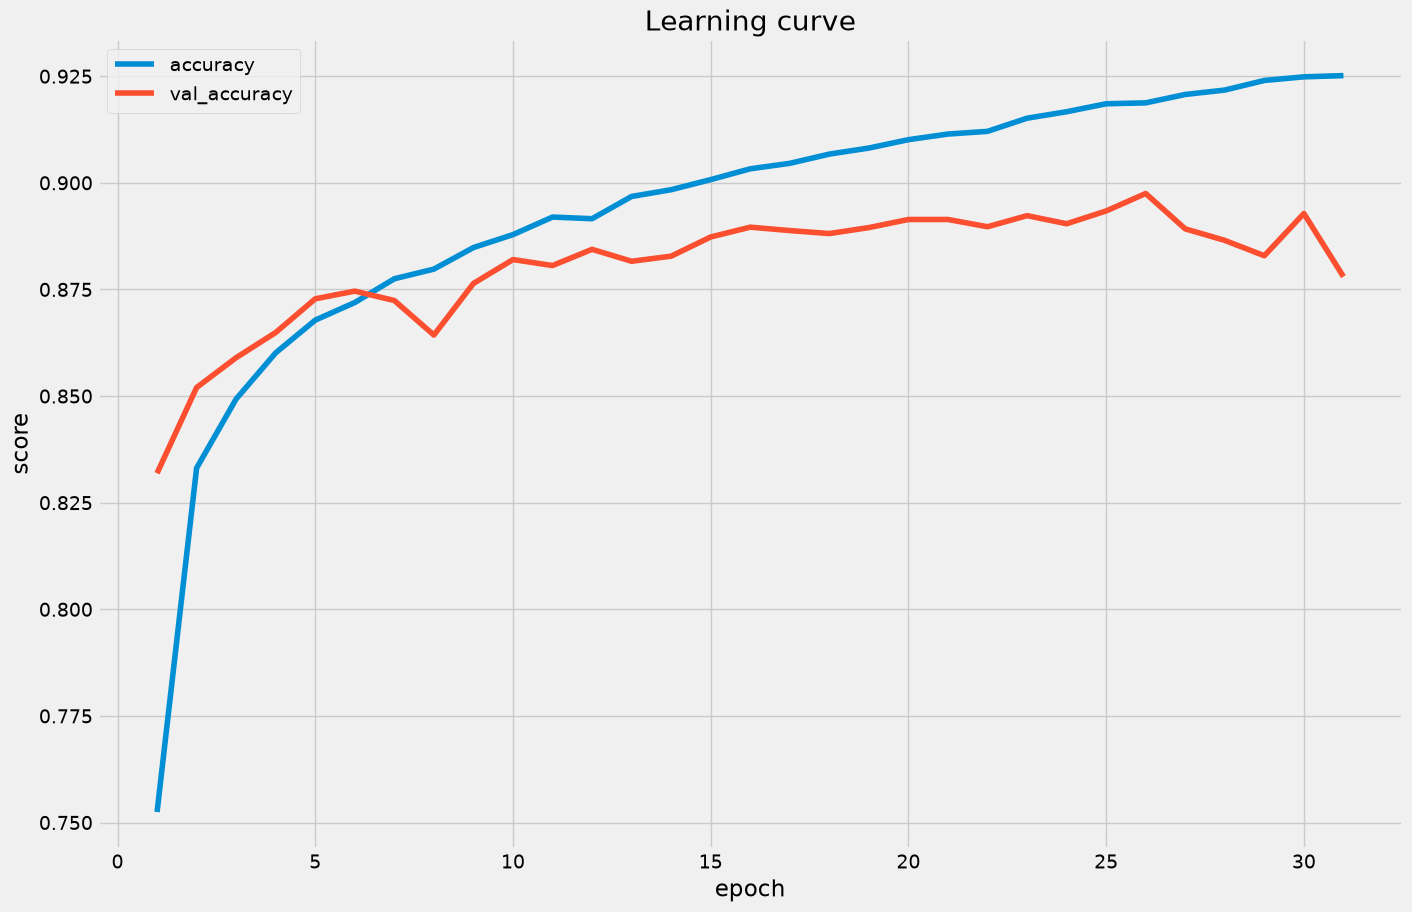

In [15]:
with plt.style.context("fivethirtyeight"):
  ax = df_history.plot(x="epoch", y=["accuracy", "val_accuracy"], figsize=(15,10), title="Learning curve");
  ax.set_ylabel("score")

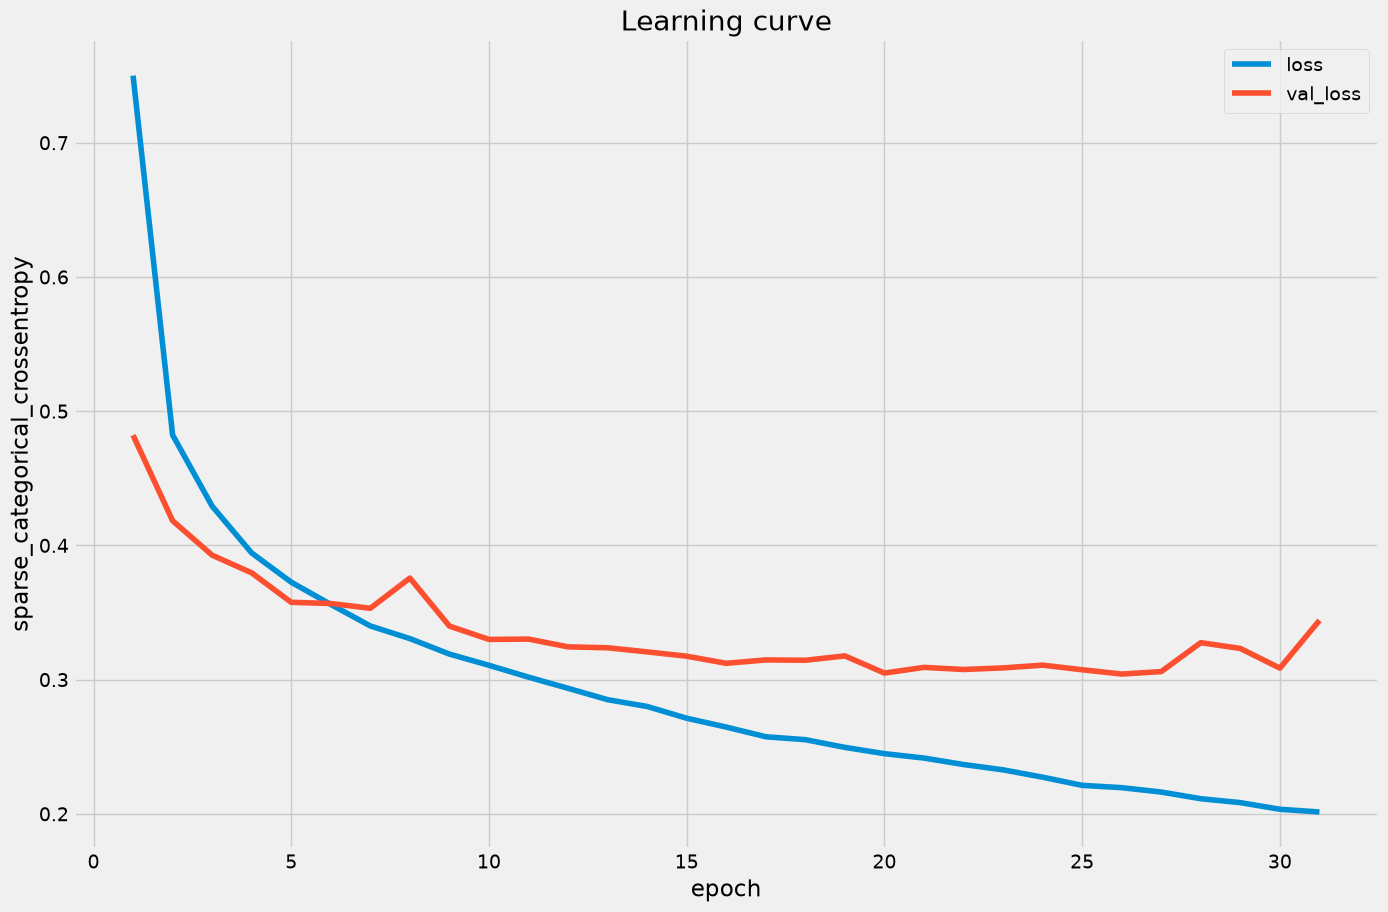

In [16]:
with plt.style.context("fivethirtyeight"):
  ax = df_history.plot(x="epoch", y=["loss", "val_loss"], figsize=(15,10), title="Learning curve");
  ax.set_ylabel(model.loss)

## Perform Prediction

Showing X_test[8577], Label: 8, Clothing Article: Bag


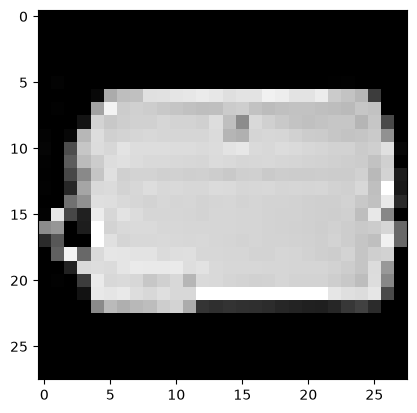

In [17]:
# Select a random observation
img_idx = np.random.randint(0,len(X_test)-1)
print(f'Showing X_test[{img_idx}], Label: {y_test[img_idx]}, Clothing Article: {class_names[y_test[img_idx]]}')
plt.imshow(X_test[img_idx], cmap="gray");

In [18]:
y_pred_scores = model.predict(X_test[[img_idx]])

# Create a dictionary with key=class label and value=its corresponding probability 
dict_probabilities = dict(zip(np.unique(y_test), y_pred_scores[0]))
print(f'Predicted probabilities: {dict_probabilities}')
predicted_class = max(dict_probabilities, key=dict_probabilities.get)
print(f'Predicted class: {predicted_class}, Clothing Article: {class_names[predicted_class]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted probabilities: {np.uint8(0): np.float32(1.2070191e-05), np.uint8(1): np.float32(9.840956e-09), np.uint8(2): np.float32(6.3208427e-07), np.uint8(3): np.float32(3.3281363e-08), np.uint8(4): np.float32(4.9404457e-07), np.uint8(5): np.float32(2.4459202e-06), np.uint8(6): np.float32(2.2595325e-06), np.uint8(7): np.float32(7.142313e-08), np.uint8(8): np.float32(0.999982), np.uint8(9): np.float32(4.5863548e-08)}
Predicted class: 8, Clothing Article: Bag
